## Importaremos bibliotecas: pandas y numpy y llamaremos pseudodatos

In [ ]:
import pandas as pd
import numpy as np
import random

In [ ]:
# Configuramos la semilla para reproducibilidad
np.random.seed(42)


In [ ]:
# Generamos los datos sintéticos
user_id = range(1, 301)
app_version = np.random.choice(['1.0', '1.1', '1.2', '1.3'], 300)
platform = np.random.choice(['Android', 'iOS'], 300)
session_duration = np.random.randint(1, 180, 300)
number_of_sessions = np.random.randint(1, 20, 300)
country = np.random.choice(['USA', 'Canada', 'Mexico', 'UK', 'Germany', 'France', 'Spain', 'Italy'], 300)
user_feedback = np.random.randint(1, 6, 300)


In [ ]:
# Creamos el DataFrame
data = pd.DataFrame({
    'user_id': user_id,
    'app_version': app_version,
    'platform': platform,
    'session_duration': session_duration,
    'number_of_sessions': number_of_sessions,
    'country': country,
    'user_feedback': user_feedback
})


In [ ]:
# Guardamos los datos en un archivo CSV
data.to_csv('user_app_data.csv', index=False)
print("Datos generados y guardados en 'user_app_data.csv'")


Datos generados y guardados en 'user_app_data.csv'


In [ ]:
# Para enviar archivo via plataforma , exigencia de prueba real
import zipfile

# Nombre del archivo CSV a comprimir
csv_file = 'user_app_data.csv'
# Nombre del archivo ZIP de salida
zip_file = 'user_app_data.zip'

# Comprimir el archivo CSV
with zipfile.ZipFile(zip_file, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(csv_file, arcname=csv_file)

print(f"El archivo '{csv_file}' ha sido comprimido en '{zip_file}'.")

El archivo 'user_app_data.csv' ha sido comprimido en 'user_app_data.zip'.


In [ ]:
print(f"El DataFrame tiene {data.shape[0]} filas y {data.shape[1]} columnas.")

El DataFrame tiene 300 filas y 7 columnas.


In [ ]:
print("Información del DataFrame:")
data.info()

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   user_id             300 non-null    int64 
 1   app_version         300 non-null    object
 2   platform            300 non-null    object
 3   session_duration    300 non-null    int64 
 4   number_of_sessions  300 non-null    int64 
 5   country             300 non-null    object
 6   user_feedback       300 non-null    int64 
dtypes: int64(4), object(3)
memory usage: 16.5+ KB


In [ ]:
print("\nEstadísticas descriptivas del DataFrame:")
data.describe()


Estadísticas descriptivas del DataFrame:


,user_id,session_duration,number_of_sessions,user_feedback
count,300.000000,300.000000,300.000000,300.000000
mean,150.500000,95.840000,9.596667,2.926667
std,86.746758,51.922773,5.672853,1.449699
min,1.000000,1.000000,1.000000,1.000000
25%,75.750000,51.250000,5.000000,2.000000
50%,150.500000,100.500000,9.000000,3.000000
75%,225.250000,141.250000,15.000000,4.000000
max,300.000000,179.000000,19.000000,5.000000


In [ ]:
num_duplicates = data.duplicated().sum()
print(f"Número de filas duplicadas en el DataFrame: {num_duplicates}")

Número de filas duplicadas en el DataFrame: 0


In [ ]:
print("Filas con valores nulos:")
display(data[data.isnull().any(axis=1)])

Filas con valores nulos:


,user_id,app_version,platform,session_duration,number_of_sessions,country,user_feedback


## Detección de Valores Atípicos (Outliers)

Los **valores atípicos** o **outliers** son puntos de datos que se desvían significativamente de otras observaciones. Pueden ser el resultado de errores en la medición, errores de entrada de datos, o pueden indicar una novedad en los datos. Su identificación es crucial porque pueden afectar negativamente el rendimiento de los modelos de aprendizaje automático y la interpretación de los análisis estadísticos.

Existen varios métodos para detectar outliers; uno de los más comunes es el método del **Rango Intercuartílico (IQR)**.

In [ ]:
# Identificación de columnas numéricas
numerical_cols = data.select_dtypes(include=np.number).columns

print("--- Detección de Outliers (Valores Atípicos) usando el método IQR ---")

# Bucle para cada columna numérica
for col in numerical_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identificar outliers
    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    if not outliers.empty:
        print(f"\nColumna: '{col}'")
        print(f"  Q1 (Cuartil 1): {Q1:.2f}")
        print(f"  Q3 (Cuartil 3): {Q3:.2f}")
        print(f"  IQR (Rango Intercuartílico): {IQR:.2f}")
        print(f"  Límite Inferior (Lower Bound): {lower_bound:.2f}")
        print(f"  Límite Superior (Upper Bound): {upper_bound:.2f}")
        print(f"  Se encontraron {len(outliers)} outliers en la columna '{col}':")
        display(outliers[['user_id', col]])
    else:
        print(f"\nColumna: '{col}'")
        print(f"  No se encontraron outliers en la columna '{col}' usando el método IQR.")

--- Detección de Outliers (Valores Atípicos) usando el método IQR ---

Columna: 'user_id'
  No se encontraron outliers en la columna 'user_id' usando el método IQR.

Columna: 'session_duration'
  No se encontraron outliers en la columna 'session_duration' usando el método IQR.

Columna: 'number_of_sessions'
  No se encontraron outliers en la columna 'number_of_sessions' usando el método IQR.

Columna: 'user_feedback'
  No se encontraron outliers en la columna 'user_feedback' usando el método IQR.


## Visualización de Outliers con Box Plots

Los diagramas de caja (box plots) son una excelente herramienta visual para identificar valores atípicos. Muestran la distribución de los datos a través de sus cuartiles, y los puntos que se extienden más allá de los 'bigotes' del diagrama son considerados outliers.

--- Visualización de Outliers (Valores Atípicos) con Box Plots ---


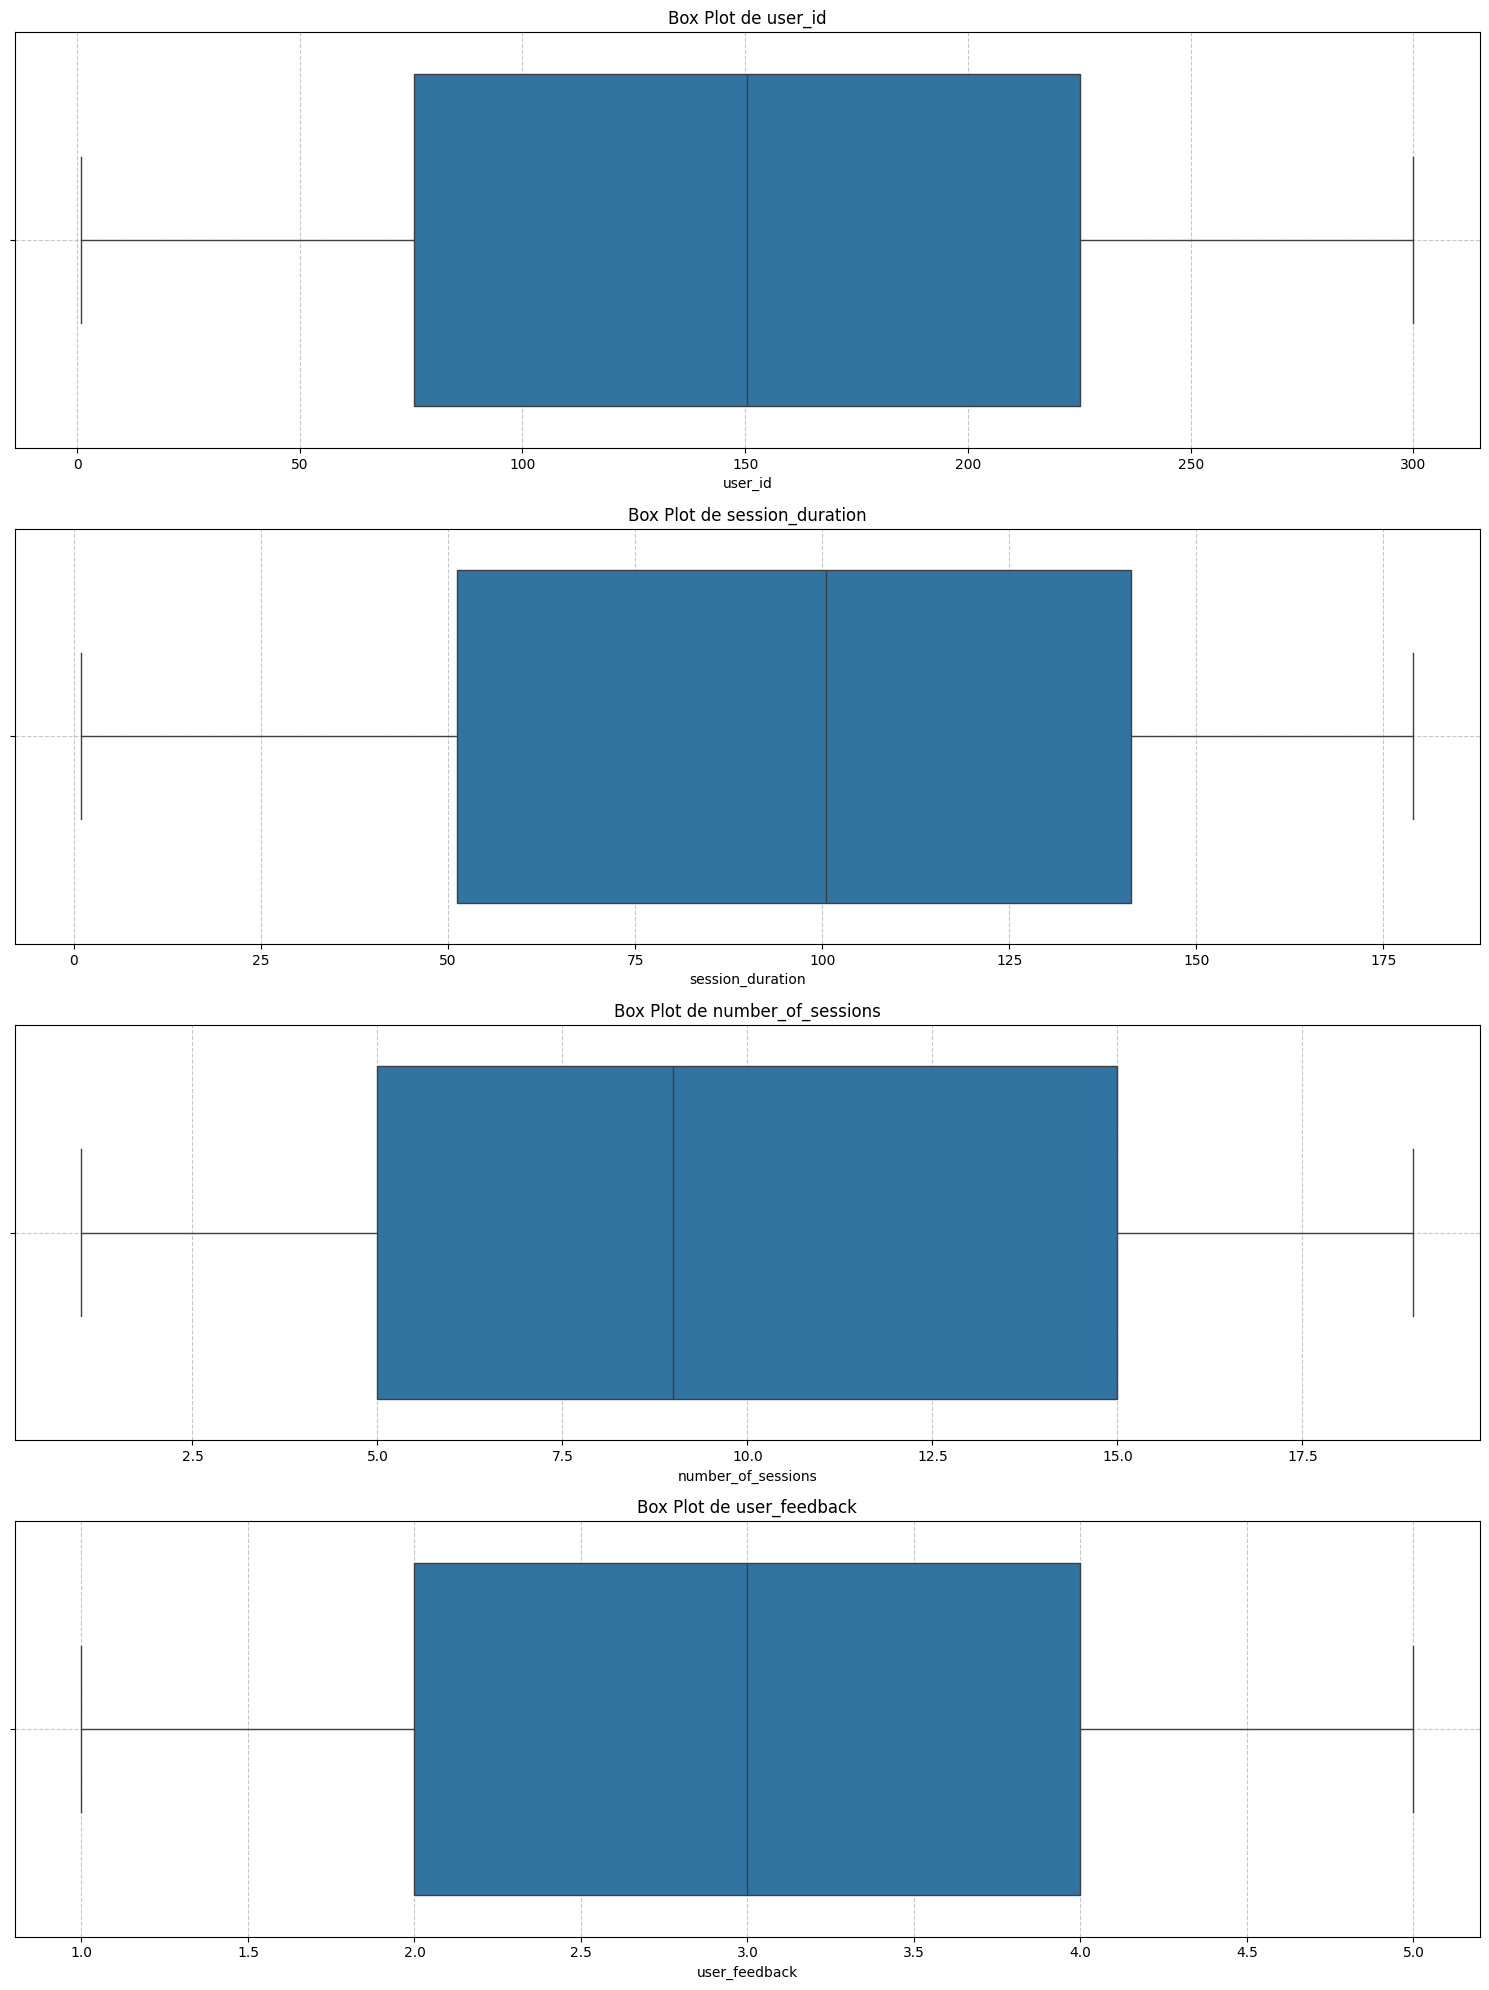

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Visualización de Outliers (Valores Atípicos) con Box Plots ---")

plt.figure(figsize=(15, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    plt.subplot(len(numerical_cols), 1, i + 1)
    sns.boxplot(x=data[col])
    plt.title(f'Box Plot de {col}')
    plt.xlabel(col)
    plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# diagrama de valores extremos o inusuales , dentro de lo esperados asignado aleatoriamente

## Identificación de Inconsistencias en Texto (Variaciones de Mayúsculas/Minúsculas)



In [ ]:
# Identificación de columnas categóricas (o de tipo 'object')
categorical_cols = data.select_dtypes(include='object').columns

print("--- Identificación de Inconsistencias de Capitalización ---")

for col in categorical_cols:
    # Obtener valores únicos originales
    original_unique_values = data[col].unique()

    # Convertir todos los valores a minúsculas y obtener los únicos
    lowercase_unique_values = data[col].str.lower().unique()

    # Crear un diccionario para mapear valores en minúsculas a sus variantes originales
    variations = {}
    for val in original_unique_values:
        lower_val = val.lower()
        if lower_val not in variations:
            variations[lower_val] = []
        variations[lower_val].append(val)

    found_inconsistency = False
    for lower_val, original_vals in variations.items():
        if len(original_vals) > 1:
            if not found_inconsistency:
                print(f"\nColumna: '{col}' - Se encontraron inconsistencias:")
                found_inconsistency = True
            print(f"  Variantes de '{lower_val}': {original_vals}")

    if not found_inconsistency:
        print(f"\nColumna: '{col}' - No se encontraron inconsistencias de capitalización significativas.")

--- Identificación de Inconsistencias de Capitalización ---

Columna: 'app_version' - No se encontraron inconsistencias de capitalización significativas.

Columna: 'platform' - No se encontraron inconsistencias de capitalización significativas.

Columna: 'country' - No se encontraron inconsistencias de capitalización significativas.


## Visualización: Países con Mayor Número de Conexiones

Vamos a crear un gráfico de barras para identificar qué países tienen la mayor cantidad de sesiones o usuarios, lo que nos dará una idea de la distribución geográfica de nuestra base de usuarios.

/tmp/ipykernel_13122/2282787607.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=data['country'], order=data['country'].value_counts().index, palette='viridis')


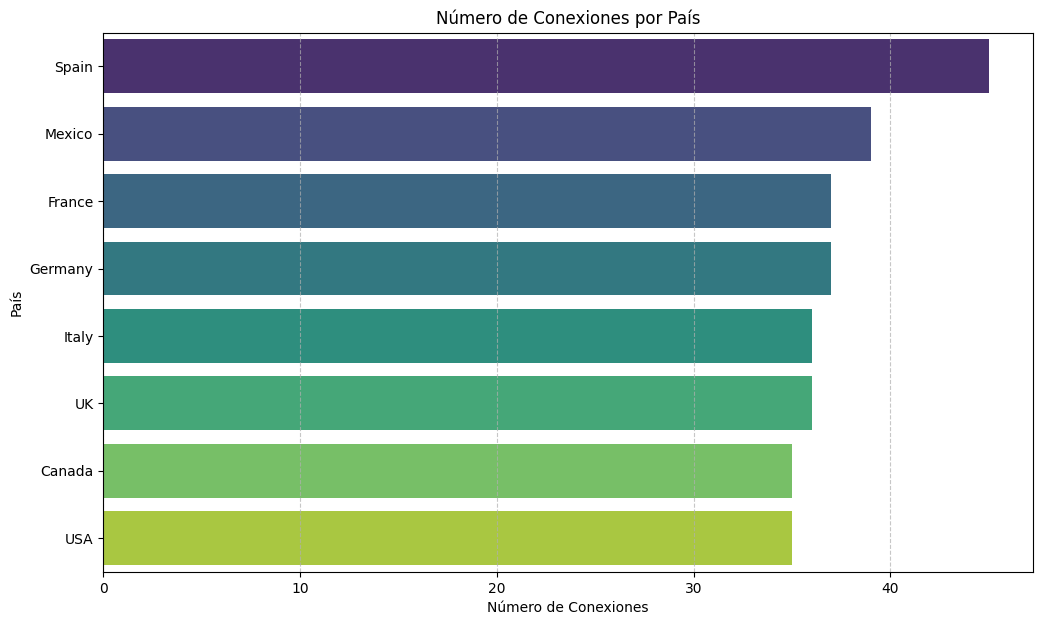

In [ ]:
plt.figure(figsize=(12, 7))
sns.countplot(y=data['country'], order=data['country'].value_counts().index, palette='viridis')
plt.title('Número de Conexiones por País')
plt.xlabel('Número de Conexiones')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Uso de Plataformas por País
Relación entre el país y la plataforma utilizada, generaremos un gráfico de barras apiladas. Esto nos permitirá ver la distribución de Android e iOS en cada país.

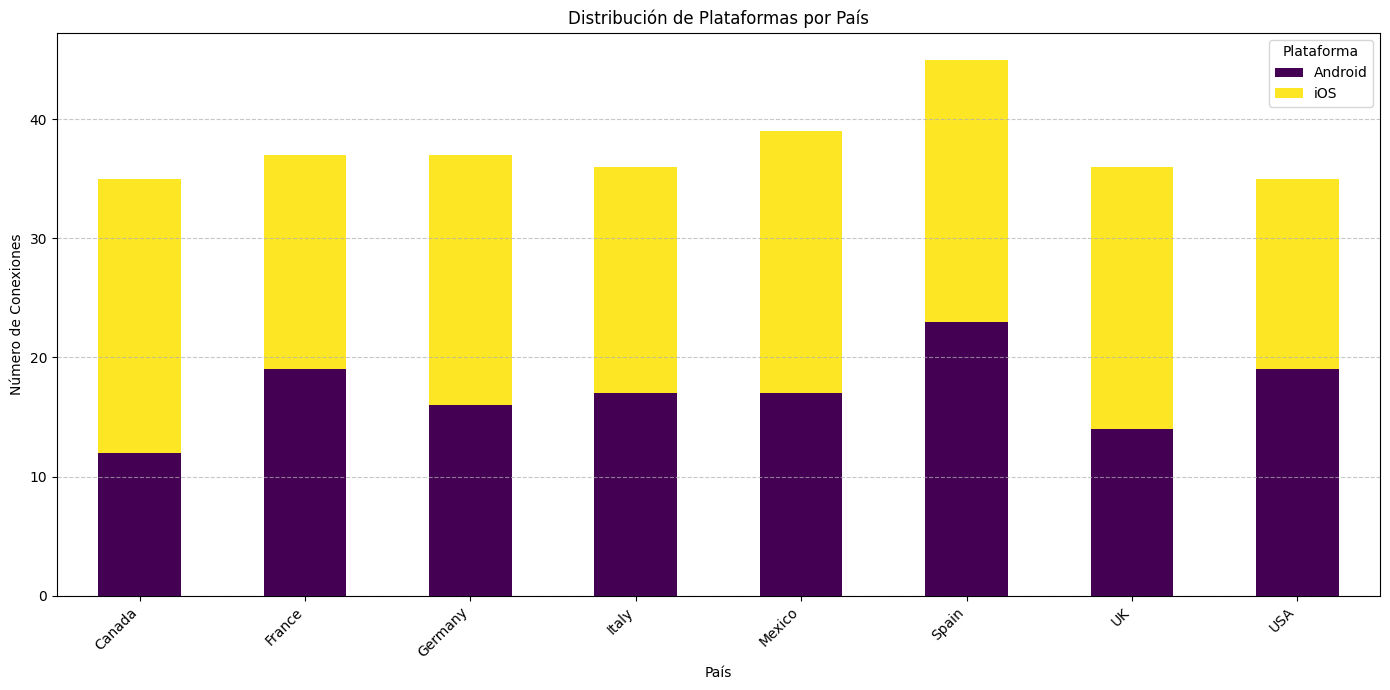

In [ ]:
# Contar el número de ocurrencias de cada plataforma por país
platform_country_counts = data.groupby(['country', 'platform']).size().unstack(fill_value=0)

# Crear el gráfico de barras apiladas
platform_country_counts.plot(kind='bar', stacked=True, figsize=(14, 7), cmap='viridis')

plt.title('Distribución de Plataformas por País')
plt.xlabel('País')
plt.ylabel('Número de Conexiones')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Plataforma')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Paises con Mayor Tiempo de Conexión

Este gráfico de barras muestra el tiempo total de conexión por país, lo que nos ayudará a identificar qué países contribuyen con la mayor cantidad de tiempo de uso en la aplicación.

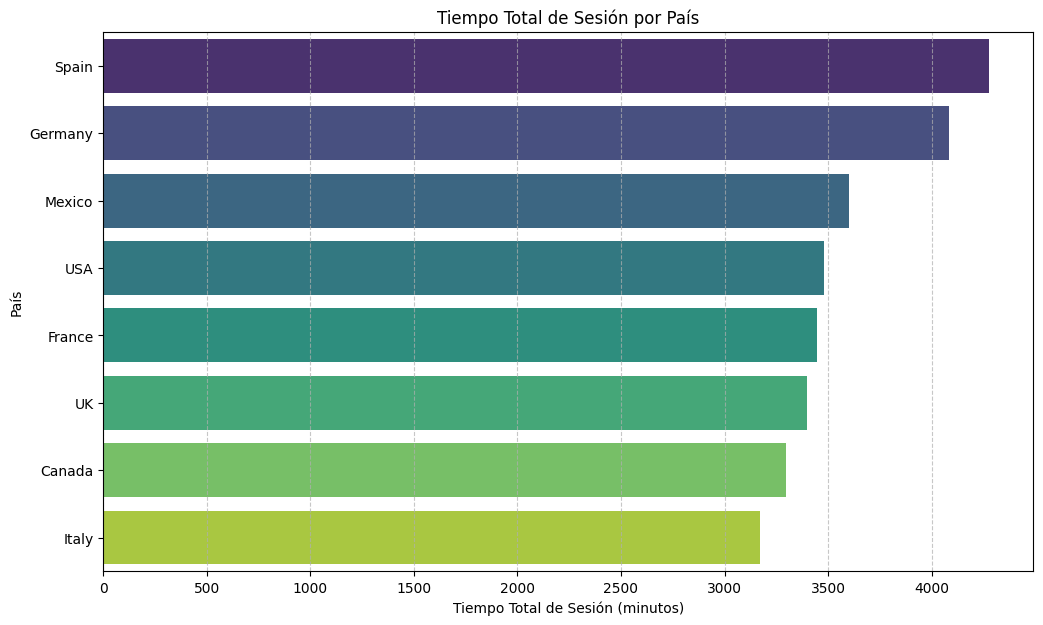

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Verifica si el DataFrame 'data' está definido. Si no, lo recrea.
# Esto maneja casos donde el kernel pudo haber sido reiniciado o celdas previas no se ejecutaron.
if 'data' not in globals():
    # Regenerando datos sintéticos (copiado de celdas anteriores para asegurar que 'data' esté definida)
    np.random.seed(42) # Asegura la reproducibilidad para este bloque aislado si es necesario

    user_id = range(1, 301)
    app_version = np.random.choice(['1.0', '1.1', '1.2', '1.3'], 300)
    platform = np.random.choice(['Android', 'iOS'], 300)
    session_duration_values = np.random.randint(1, 180, 300)
    number_of_sessions_values = np.random.randint(1, 20, 300)
    country_values = np.random.choice(['USA', 'Canada', 'Mexico', 'UK', 'Germany', 'France', 'Spain', 'Italy'], 300)
    user_feedback_values = np.random.randint(1, 6, 300)

    data = pd.DataFrame({
        'user_id': user_id,
        'app_version': app_version,
        'platform': platform,
        'session_duration': session_duration_values,
        'number_of_sessions': number_of_sessions_values,
        'country': country_values,
        'user_feedback': user_feedback_values
    })
    print("DataFrame 'data' fue re-creado porque no estaba definido.\n")

country_session_duration = data.groupby('country')['session_duration'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 7))
sns.barplot(x='session_duration', y='country', hue='country', data=country_session_duration, palette='viridis', legend=False)
plt.title('Tiempo Total de Sesión por País')
plt.xlabel('Tiempo Total de Sesión (minutos)')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Correlación entre Tiempo de Conexión y Satisfacción por País

Aquí calcularemos el coeficiente de correlación de Pearson entre `session_duration` (tiempo de conexión) y `user_feedback` (satisfacción del usuario) para cada país. Una correlación positiva indicaría que a mayor tiempo de conexión, mayor satisfacción, mientras que una negativa indicaría lo contrario.

Correlación entre 'session_duration' y 'user_feedback' por País:


,country,correlation
0,France,0.290727
1,USA,0.183704
2,UK,0.030022
3,Spain,0.025918
4,Italy,0.010883
5,Canada,-0.086852
6,Mexico,-0.164793
7,Germany,-0.182120


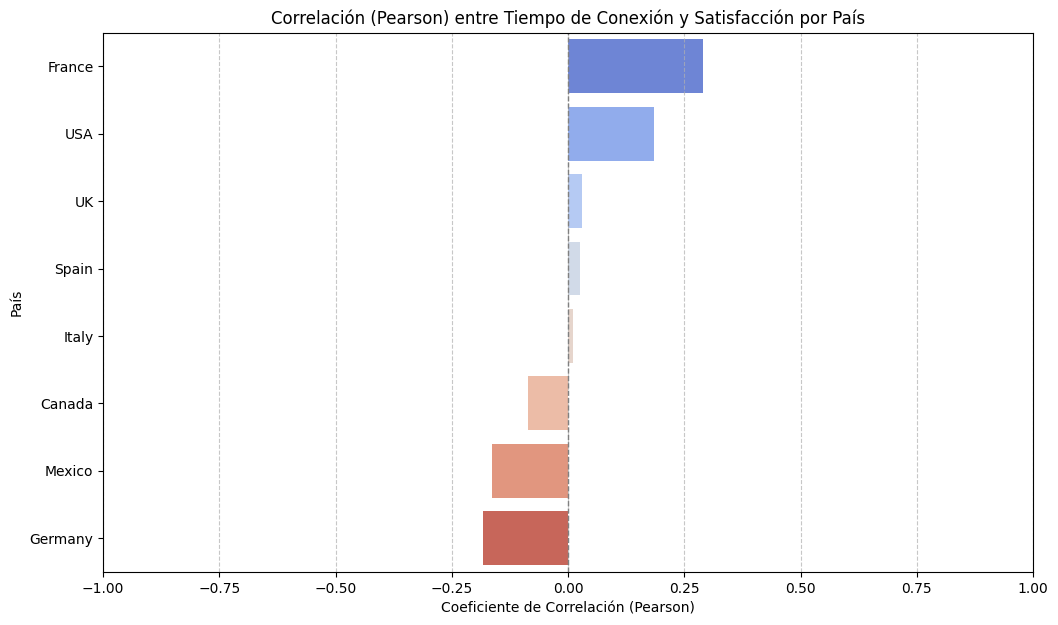

In [5]:
correlation_by_country = []

for country_name in data['country'].unique():
    country_data = data[data['country'] == country_name]

    # Asegurarse de que haya suficiente varianza y datos para calcular la correlación
    if len(country_data) > 1 and country_data['session_duration'].std() > 0 and country_data['user_feedback'].std() > 0:
        correlation = country_data['session_duration'].corr(country_data['user_feedback'])
        correlation_by_country.append({'country': country_name, 'correlation': correlation})
    else:
        correlation_by_country.append({'country': country_name, 'correlation': None}) # O NaN, si prefieres

correlation_df = pd.DataFrame(correlation_by_country)

# Eliminar países donde no se pudo calcular la correlación (ej. datos insuficientes/sin varianza)
correlation_df = correlation_df.dropna(subset=['correlation'])

# Ordenar por correlación para una mejor visualización
correlation_df = correlation_df.sort_values(by='correlation', ascending=False).reset_index(drop=True)

print("Correlación entre 'session_duration' y 'user_feedback' por País:")
display(correlation_df)

# Visualizar la correlación
plt.figure(figsize=(12, 7))
sns.barplot(x='correlation', y='country', hue='country', data=correlation_df, palette='coolwarm', legend=False)
plt.title('Correlación (Pearson) entre Tiempo de Conexión y Satisfacción por País')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.ylabel('País')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(-1, 1) # La correlación va de -1 a 1
plt.axvline(0, color='gray', linestyle='--', linewidth=1) # Línea en 0 para referencia
plt.show()

## Correlación por País y Versión de la Aplicación (Tipo de Software)

Para entender mejor la relación, analizaremos la correlación entre `session_duration` y `user_feedback` para cada `country` y `app_version`.

Correlación entre 'session_duration' y 'user_feedback' por País y Versión de la Aplicación:


,country,app_version,correlation
0,Canada,1.1,0.343818
1,Canada,1.2,-0.188905
2,Canada,1.0,-0.241366
3,Canada,1.3,-0.480752
4,France,1.1,0.804489
5,France,1.0,0.614149
6,France,1.2,0.152501
7,France,1.3,-0.037281
8,Germany,1.3,0.101325
9,Germany,1.0,-0.099712


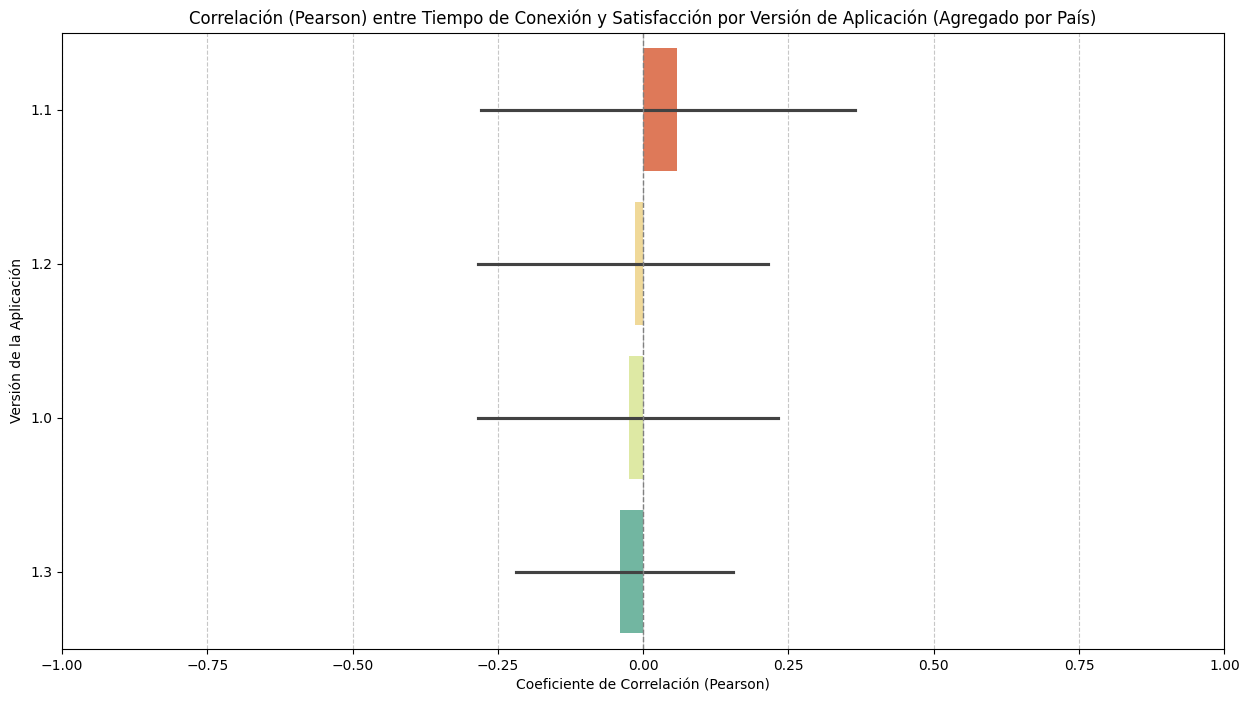

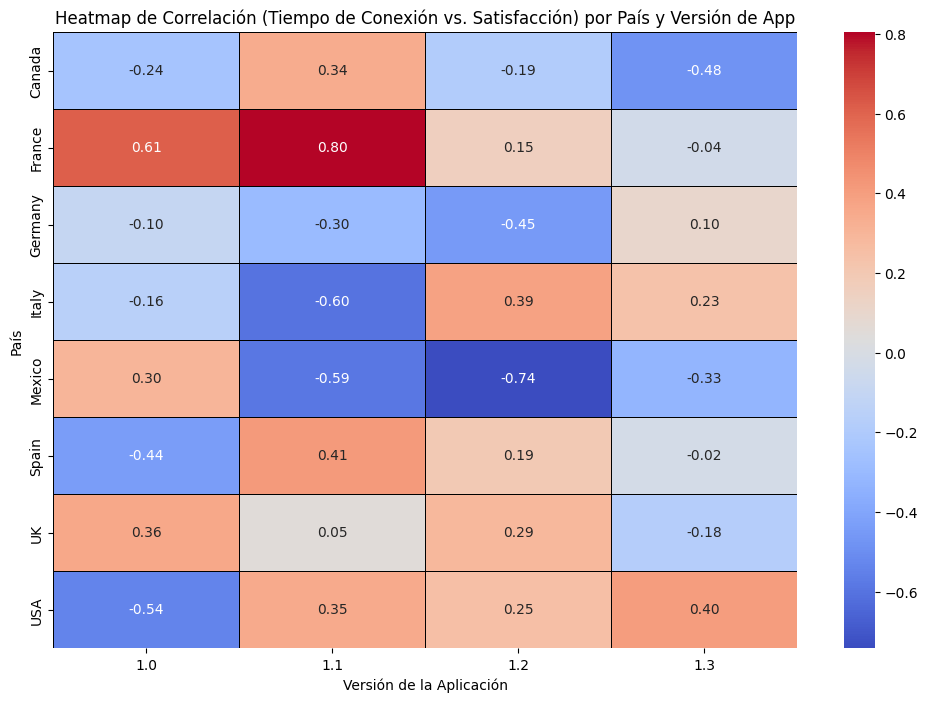

In [6]:
correlation_by_country_app_version = []

for (country_name, app_version_name), group_data in data.groupby(['country', 'app_version']):

    # Asegurarse de que haya suficiente varianza y datos para calcular la correlación
    if len(group_data) > 1 and group_data['session_duration'].std() > 0 and group_data['user_feedback'].std() > 0:
        correlation = group_data['session_duration'].corr(group_data['user_feedback'])
        correlation_by_country_app_version.append({'country': country_name, 'app_version': app_version_name, 'correlation': correlation})
    else:
        correlation_by_country_app_version.append({'country': country_name, 'app_version': app_version_name, 'correlation': None})

correlation_app_version_df = pd.DataFrame(correlation_by_country_app_version)

# Eliminar combinaciones donde no se pudo calcular la correlación
correlation_app_version_df = correlation_app_version_df.dropna(subset=['correlation'])

# Ordenar para una mejor visualización
correlation_app_version_df = correlation_app_version_df.sort_values(by=['country', 'correlation'], ascending=[True, False]).reset_index(drop=True)

print("Correlación entre 'session_duration' y 'user_feedback' por País y Versión de la Aplicación:")
display(correlation_app_version_df)

# Visualización de la correlación por país y versión de la aplicación
plt.figure(figsize=(15, 8))
sns.barplot(x='correlation', y='app_version', hue='app_version', data=correlation_app_version_df, palette='Spectral', legend=False)
plt.title('Correlación (Pearson) entre Tiempo de Conexión y Satisfacción por Versión de Aplicación (Agregado por País)')
plt.xlabel('Coeficiente de Correlación (Pearson)')
plt.ylabel('Versión de la Aplicación')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.xlim(-1, 1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.show()

# También podemos crear una visualización para ver por país
# Crear un pivot para un heatmap
correlation_pivot = correlation_app_version_df.pivot_table(index='country', columns='app_version', values='correlation')

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_pivot, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5, linecolor='black')
plt.title('Heatmap de Correlación (Tiempo de Conexión vs. Satisfacción) por País y Versión de App')
plt.xlabel('Versión de la Aplicación')
plt.ylabel('País')
plt.show()

#hay correlacion entre modelo de app y satisfaccion , tambien entre tiempo de conexion y satisfaccion sin embargo ciertos paises tiene correlacion negativa , lo que podria indicar problemas culturales o tipo de contenido